In [1]:
pip install requests beautifulsoup4 tqdm loguru

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ------------- -------------------------- 1/3 [tqdm]
   ------------- -------------------------- 1/3 [tqdm]
   -------------------------- ------------- 2/3 [loguru]
   -------------------------- ------------- 2/3 [loguru]
   ---------------------------------------- 3/3 [loguru]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import time
import glob
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


SEARCH_TEXT = "кардиоплег"
DOWNLOAD_DIR = r"C:\Users\e.turchaninova\Desktop\eis"
RESULT_XLSX = os.path.join(DOWNLOAD_DIR, "cardiopleg_all.xlsx")
RESULT_CSV = os.path.join(DOWNLOAD_DIR, "cardiopleg_all.csv")

os.makedirs(DOWNLOAD_DIR, exist_ok=True)


def wait_for_downloads(download_dir, timeout=300):
    """
    Ждём, пока закончатся загрузки.
    Для Chrome незавершённые файлы обычно имеют расширение .crdownload
    """
    start = time.time()
    while True:
        temp_files = glob.glob(os.path.join(download_dir, "*.crdownload"))
        if not temp_files:
            return True
        if time.time() - start > timeout:
            raise TimeoutError("Не дождались завершения скачивания файлов")
        time.sleep(2)


def get_driver(download_dir):
    options = webdriver.ChromeOptions()

    prefs = {
        "download.default_directory": download_dir,
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "safebrowsing.enabled": True
    }
    options.add_experimental_option("prefs", prefs)

    options.add_argument("--start-maximized")

    driver = webdriver.Chrome(options=options)
    return driver


def merge_csv_files(download_dir, result_csv, result_xlsx):
    csv_files = sorted(glob.glob(os.path.join(download_dir, "*.csv")))
    if not csv_files:
        raise FileNotFoundError("CSV-файлы не найдены")

    dfs = []
    for file in csv_files:
        try:
            # сначала пробуем utf-8-sig
            df = pd.read_csv(file, sep=";", encoding="utf-8-sig")
        except Exception:
            try:
                df = pd.read_csv(file, sep=";", encoding="cp1251")
            except Exception:
                df = pd.read_csv(file)

        df["source_file"] = os.path.basename(file)
        dfs.append(df)

    final_df = pd.concat(dfs, ignore_index=True)
    final_df.to_csv(result_csv, index=False, encoding="utf-8-sig")
    final_df.to_excel(result_xlsx, index=False)

    return final_df


driver = get_driver(DOWNLOAD_DIR)
wait = WebDriverWait(driver, 60)

try:
    # 1. Открываем страницу поиска контрактов
    driver.get("https://zakupki.gov.ru/epz/contract/search/search.html")

    # 2. Находим поле поиска и ищем "кардиоплег"
    search_input = wait.until(
        EC.presence_of_element_located((By.NAME, "searchString"))
    )
    search_input.clear()
    search_input.send_keys(SEARCH_TEXT)
    search_input.send_keys(Keys.ENTER)

    # 3. Ждём результатов
    wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "a.downLoad-search"))
    )

    time.sleep(3)

    # 4. Нажимаем кнопку выгрузки результатов поиска
    download_search_btn = driver.find_element(By.CSS_SELECTOR, "a.downLoad-search")
    driver.execute_script("arguments[0].click();", download_search_btn)

    # 5. Ждём открытия окна с параметрами выгрузки
    wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, ".dynatree-title"))
    )

    time.sleep(2)

    # 6. Ищем пункт "Все параметры" и кликаем по нему
    all_params = driver.find_element(
        By.XPATH,
        "//span[contains(@class,'dynatree-title') and normalize-space()='Все параметры']"
    )
    driver.execute_script("arguments[0].click();", all_params)

    time.sleep(2)

    # 7. Нажимаем кнопку "ДАЛЕЕ"
    next_btn = wait.until(
        EC.element_to_be_clickable((By.ID, "btn-primary"))
    )
    driver.execute_script("arguments[0].click();", next_btn)

    # 8. Ждём появления списка файлов для выгрузки
    wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "#unload-block-list .csvDownload"))
    )

    time.sleep(3)

    # 9. Собираем все кнопки "Выгрузить"
    download_buttons = driver.find_elements(By.CSS_SELECTOR, "#unload-block-list .csvDownload")

    print(f"Найдено диапазонов для выгрузки: {len(download_buttons)}")

    # 10. Кликаем каждую кнопку выгрузки
    for i in range(len(download_buttons)):
        buttons = driver.find_elements(By.CSS_SELECTOR, "#unload-block-list .csvDownload")
        btn = buttons[i]

        text = btn.text.strip()
        data_from = btn.get_attribute("data-from")
        data_to = btn.get_attribute("data-to")
        csv_name = btn.get_attribute("data-csvname")

        print(f"Скачиваю: {text} | {data_from}-{data_to} | {csv_name}")

        driver.execute_script("arguments[0].click();", btn)
        time.sleep(5)

    # 11. Ждём завершения скачиваний
    wait_for_downloads(DOWNLOAD_DIR, timeout=600)

    # 12. Объединяем CSV
    final_df = merge_csv_files(DOWNLOAD_DIR, RESULT_CSV, RESULT_XLSX)

    print("Готово.")
    print("Итоговый CSV:", RESULT_CSV)
    print("Итоговый Excel:", RESULT_XLSX)
    print("Строк в итоговом файле:", len(final_df))

finally:
    driver.quit()

Найдено диапазонов для выгрузки: 6
Скачиваю: Выгрузить | 1-500 | (1-500)_08.04.2026.csv
Скачиваю: Выгрузить | 501-1000 | (501-1000)_08.04.2026.csv
Скачиваю: Выгрузить | 1001-1500 | (1001-1500)_08.04.2026.csv
Скачиваю: Выгрузить | 1501-2000 | (1501-2000)_08.04.2026.csv
Скачиваю: Выгрузить | 2001-2500 | (2001-2500)_08.04.2026.csv
Скачиваю: Выгрузить | 2501-2911 | (2501-2911)_08.04.2026.csv
Готово.
Итоговый CSV: C:\Users\e.turchaninova\Desktop\eis\cardiopleg_all.csv
Итоговый Excel: C:\Users\e.turchaninova\Desktop\eis\cardiopleg_all.xlsx
Строк в итоговом файле: 35804


In [13]:
final_df

,Номер реестровой записи контракта,Заказчик: наименование,Заказчик: ИНН,Заказчик: КПП,Уровень бюджета,Источник финансирования контракта: наименование бюджета,Источник финансирования контракта: наименование/вид внебюджетных средств,Способ размещения заказа,Номер извещения о проведени торгов,"Дата подведения результатов определения поставщика (подрядчика, исполнителя)",...,Объект закупки: код позиции,"Объект закупки: цена за единицу, рублей","Объект закупки: количество поставленных товаров, выполненных работ, оказанных услуг","Объект закупки: сумма, рублей","Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)","Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН","Информация о поставщиках (исполнителях, подрядчиках) по контракту: КПП",Дата последнего изменения записи,Дата исполнения контракта: по контракту,source_file
0,'2254002126325000389',ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,'2540021263','254001001',NaN,NaN,Средства бюджетных учреждений,Запрос котировок в электронной форме,'0320200027925000249',28.11.2025,...,21.20.24.120-00000006,'1078.11 ',NaN,NaN,Кучма Алексеевич Эдуард,'253600948953','',08.04.2026 09:03,31.12.2026,ContractSearch(1-500)_08.04.2026.csv
1,'2254002126325000389',ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,'2540021263','254001001',NaN,NaN,Средства бюджетных учреждений,Запрос котировок в электронной форме,'0320200027925000249',28.11.2025,...,21.20.24.120-00000010,'1078.11 ',NaN,NaN,Кучма Алексеевич Эдуард,'253600948953','',08.04.2026 09:03,31.12.2026,ContractSearch(1-500)_08.04.2026.csv
2,'2254002126325000389',ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,'2540021263','254001001',NaN,NaN,Средства бюджетных учреждений,Запрос котировок в электронной форме,'0320200027925000249',28.11.2025,...,21.20.24.120-00000028,'1437.48 ',NaN,NaN,Кучма Алексеевич Эдуард,'253600948953','',08.04.2026 09:03,31.12.2026,ContractSearch(1-500)_08.04.2026.csv
3,'2254002126325000389',ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,'2540021263','254001001',NaN,NaN,Средства бюджетных учреждений,Запрос котировок в электронной форме,'0320200027925000249',28.11.2025,...,21.20.24.120-00000028,'1245.82 ',NaN,NaN,Кучма Алексеевич Эдуард,'253600948953','',08.04.2026 09:03,31.12.2026,ContractSearch(1-500)_08.04.2026.csv
4,'2254002126325000389',ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХР...,'2540021263','254001001',NaN,NaN,Средства бюджетных учреждений,Запрос котировок в электронной форме,'0320200027925000249',28.11.2025,...,21.20.24.120-00000028,'1839.32 ',NaN,NaN,Кучма Алексеевич Эдуард,'253600948953','',08.04.2026 09:03,31.12.2026,ContractSearch(1-500)_08.04.2026.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35799,'1780204820023000128',ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,'7802048200','780201001',NaN,NaN,Средства бюджетных учреждений,Электронный аукцион,'0372100011722000834',12.01.2023,...,32.50.13.190-00007604,'11348.00 ','6','68088.00',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МЕДИ...",'4703078047','470301001',20.02.2024 15:00,31.03.2024,ContractSearch(501-1000)_08.04.2026.csv
35800,'1780204820023000128',ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,'7802048200','780201001',NaN,NaN,Средства бюджетных учреждений,Электронный аукцион,'0372100011722000834',12.01.2023,...,32.50.22.190-00005223,'39541.97 ','3','118625.91',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МЕДИ...",'4703078047','470301001',20.02.2024 15:00,31.03.2024,ContractSearch(501-1000)_08.04.2026.csv
35801,'1780204820023000128',ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,'7802048200','780201001',NaN,NaN,Средства бюджетных учреждений,Электронный аукцион,'0372100011722000834',12.01.2023,...,32.50.22.190-00005104,'84885.00 ','1','84885.00',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МЕДИ...",'4703078047','470301001',20.02.2024 15:00,31.03.2024,ContractSearch(501-1000)_08.04.2026.csv
35802,'17802048200

In [17]:
# бронза

import hashlib
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()


COLUMN_MAPPING = {
    "Номер реестровой записи контракта": "registry_contract_id",
    "Заказчик: наименование": "customer_name",
    "Заказчик: ИНН": "customer_inn",
    "Заказчик: КПП": "customer_kpp",
    "Уровень бюджета": "budget_level",
    "Источник финансирования контракта: наименование бюджета": "budget_source_name",
    "Источник финансирования контракта: наименование/вид внебюджетных средств": "extra_budget_source_type",
    "Способ размещения заказа": "procurement_method",
    "Номер извещения о проведени торгов": "notice_number",
    "Дата подведения результатов определения поставщика (подрядчика, исполнителя)": "supplier_result_date",
    "Реквизиты документа, подтверждающего основание заключения контракта": "basis_document_details",
    "Контракт: дата": "contract_date",
    "Контракт: номер": "contract_number",
    "Предмет контракта": "contract_subject",
    "Цена контракта": "contract_price",
    "Код бюджетной классификации": "budget_classification_code",
    "КОСГУ": "kosgu_code",
    "КВР": "kvr_code",
    "Идентификационный код закупки (ИКЗ)": "ikz_code",
    "Объект закупки: наименование товаров, работ, услуг": "purchase_object_name",
    "Объект закупки: код позиции": "purchase_object_code",
    "Объект закупки: цена за единицу, рублей": "unit_price_rub",
    "Объект закупки: количество поставленных товаров, выполненных работ, оказанных услуг": "delivered_quantity",
    "Объект закупки: сумма, рублей": "purchase_object_amount_rub",
    "Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)": "supplier_name",
    "Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН": "supplier_inn",
    "Информация о поставщиках (исполнителях, подрядчиках) по контракту: КПП": "supplier_kpp",
    "Дата последнего изменения записи": "last_modified_date",
    "Дата исполнения контракта: по контракту": "contract_execution_date",
    "source_file": "source_file",
}


def get_postgres_url(db_name: str) -> URL:
    return URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=db_name
    )


def create_database_if_not_exists() -> None:
    system_engine = create_engine(get_postgres_url("postgres"), isolation_level="AUTOCOMMIT")

    with system_engine.connect() as conn:
        exists = conn.execute(
            text("SELECT 1 FROM pg_database WHERE datname = :db_name"),
            {"db_name": DB_NAME}
        ).scalar()

        if not exists:
            conn.execute(text(f'CREATE DATABASE "{DB_NAME}"'))
            print(f'База данных "{DB_NAME}" создана')
        else:
            print(f'База данных "{DB_NAME}" уже существует')


def get_engine():
    return create_engine(get_postgres_url(DB_NAME))


def prepare_raw_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # оставляем только уникальные колонки
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # переименовываем известные столбцы
    renamed_columns = {}
    unknown_counter = 1

    for col in df.columns:
        if col in COLUMN_MAPPING:
            renamed_columns[col] = COLUMN_MAPPING[col]
        else:
            renamed_columns[col] = f"extra_col_{unknown_counter}"
            unknown_counter += 1

    df = df.rename(columns=renamed_columns)

    # приводим все значения к строкам
    for col in df.columns:
        df[col] = df[col].astype(str).fillna("")

    # hash по всей строке
    hash_source = df.astype(str).agg("||".join, axis=1)
    df["hash_key"] = hash_source.apply(lambda x: hashlib.md5(x.encode("utf-8")).hexdigest())

    # убираем дубли внутри текущей загрузки
    df = df.drop_duplicates(subset=["hash_key"]).reset_index(drop=True)

    return df


def create_raw_table_if_not_exists(engine, df: pd.DataFrame) -> None:
    columns_sql = []

    for col in df.columns:
        if col == "hash_key":
            columns_sql.append(f'{col} TEXT UNIQUE')
        else:
            columns_sql.append(f'{col} TEXT')

    create_sql = f"""
    CREATE TABLE IF NOT EXISTS raw_contracts (
        id BIGSERIAL PRIMARY KEY,
        {", ".join(columns_sql)},
        loaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """

    with engine.begin() as conn:
        conn.execute(text(create_sql))


def insert_without_duplicates(engine, df: pd.DataFrame) -> None:
    temp_table = "raw_contracts_stage"

    df.to_sql(temp_table, engine, if_exists="replace", index=False)

    insert_columns = [col for col in df.columns]
    select_columns = [f's.{col}' for col in df.columns]

    insert_sql = f"""
    INSERT INTO raw_contracts ({", ".join(insert_columns)})
    SELECT {", ".join(select_columns)}
    FROM {temp_table} s
    LEFT JOIN raw_contracts t
        ON s.hash_key = t.hash_key
    WHERE t.hash_key IS NULL;
    """

    drop_sql = f"DROP TABLE IF EXISTS {temp_table};"

    with engine.begin() as conn:
        conn.execute(text(insert_sql))
        conn.execute(text(drop_sql))


def load_final_df_to_postgres(final_df: pd.DataFrame) -> None:
    create_database_if_not_exists()
    engine = get_engine()

    prepared_df = prepare_raw_dataframe(final_df)
    create_raw_table_if_not_exists(engine, prepared_df)
    insert_without_duplicates(engine, prepared_df)

    print("Данные успешно загружены в таблицу raw_contracts без дублей")
    print("Строк в текущей загрузке после очистки:", len(prepared_df))


if __name__ == "__main__":
    # from module_01_extract import extract_contracts
    # final_df = extract_contracts()
    load_final_df_to_postgres(final_df)
    pass

База данных "zakupki" уже существует
Данные успешно загружены в таблицу raw_contracts без дублей
Строк в текущей загрузке после очистки: 32883


In [123]:
# silver

import re
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


REQUIRED_COLUMNS = [
    "registry_contract_id",
    "customer_name",
    "customer_inn",
    "customer_kpp",
    "budget_level",
    "budget_source_name",
    "extra_budget_source_type",
    "procurement_method",
    "notice_number",
    "supplier_result_date",
    "basis_document_details",
    "contract_date",
    "contract_number",
    "contract_subject",
    "contract_price",
    "budget_classification_code",
    "kosgu_code",
    "kvr_code",
    "ikz_code",
    "purchase_object_name",
    "purchase_object_code",
    "unit_price_rub",
    "delivered_quantity",
    "purchase_object_amount_rub",
    "supplier_name",
    "supplier_inn",
    "supplier_kpp",
]

STRING_COLUMNS = [
    "registry_contract_id",
    "customer_name",
    "customer_inn",
    "customer_kpp",
    "budget_level",
    "budget_source_name",
    "extra_budget_source_type",
    "procurement_method",
    "notice_number",
    "supplier_result_date",
    "basis_document_details",
    "contract_number",
    "contract_subject",
    "budget_classification_code",
    "kosgu_code",
    "kvr_code",
    "ikz_code",
    "purchase_object_name",
    "purchase_object_code",
    "supplier_name",
    "supplier_inn",
    "supplier_kpp",
]

FLOAT_COLUMNS = [
    "contract_price",
    "unit_price_rub",
    "purchase_object_amount_rub",
]

INT_COLUMNS = [
    "delivered_quantity",
]


def clean_quotes_and_spaces(value):
    if pd.isna(value):
        return None

    value = str(value)
    value = value.replace('"', "").replace("'", "").replace("«", "").replace("»", "")
    value = value.replace("\xa0", " ")
    value = re.sub(r"\s+", " ", value).strip()

    if value == "" or value.lower() == "nan":
        return None

    return value


def clean_string_series(series: pd.Series) -> pd.Series:
    return series.apply(clean_quotes_and_spaces).astype("string")


def clean_float_value(value):
    if pd.isna(value):
        return None

    value = str(value)
    value = value.replace('"', "").replace("'", "").replace("«", "").replace("»", "")
    value = value.replace(" ", "").replace("\xa0", "")
    value = value.replace(",", ".")

    value = re.sub(r"[^0-9.\-]", "", value)

    if value in {"", ".", "-", "nan"}:
        return None

    try:
        return float(value)
    except Exception:
        return None


def clean_int_value(value):
    if pd.isna(value):
        return None

    value = str(value)
    value = value.replace('"', "").replace("'", "").replace("«", "").replace("»", "")
    value = value.replace(" ", "").replace("\xa0", "")
    value = value.replace(",", ".")

    value = re.sub(r"[^0-9.\-]", "", value)

    if value in {"", ".", "-", "nan"}:
        return None

    try:
        return int(float(value))
    except Exception:
        return None


def extract_and_transform() -> pd.DataFrame:
    engine = get_engine()

    df = pd.read_sql("SELECT * FROM raw_contracts", engine)
    print("1. Загружено строк из raw_contracts:", len(df))

    available_columns = [col for col in REQUIRED_COLUMNS if col in df.columns]
    df = df[available_columns].copy()

    print("2. После выбора нужных столбцов:", len(df))
    print("Используемые столбцы:")
    print(available_columns)

    # удаление дублей
    df = df.drop_duplicates().reset_index(drop=True)
    print("3. После первого удаления дублей:", len(df))

    # очистка строковых полей
    for col in STRING_COLUMNS:
        if col in df.columns:
            df[col] = clean_string_series(df[col])

    # обработка даты
    if "contract_date" in df.columns:
        df["contract_date"] = df["contract_date"].apply(clean_quotes_and_spaces)

        print("4. Примеры дат до преобразования:")
        print(df["contract_date"].dropna().head(10))

        df["contract_date"] = pd.to_datetime(
            df["contract_date"],
            errors="coerce",
            dayfirst=True
        )

        print("5. Непустых дат после преобразования:", df["contract_date"].notna().sum())

        df = df[df["contract_date"].notna()].copy()
        print("6. После удаления строк без даты:", len(df))

        cutoff_date = pd.Timestamp("2019-01-01")
        df = df[df["contract_date"] >= cutoff_date].copy()
        print("7. После фильтра по последним 365 дням:", len(df))

    # числовые поля float
    for col in FLOAT_COLUMNS:
        if col in df.columns:
            df[col] = df[col].apply(clean_float_value)

    # целочисленные поля
    for col in INT_COLUMNS:
        if col in df.columns:
            df[col] = df[col].apply(clean_int_value)

    # повторное удаление дублей после нормализации
    df = df.drop_duplicates().reset_index(drop=True)
    print("8. После финального удаления дублей:", len(df))

    return df


def load_to_silver(df: pd.DataFrame) -> None:
    engine = get_engine()

    with engine.begin() as conn:
        conn.execute(text("DROP TABLE IF EXISTS silver_contracts"))

    df.to_sql("silver_contracts", engine, if_exists="replace", index=False)

    print("Таблица silver_contracts успешно создана")
    print("Количество строк в silver_contracts:", len(df))


if __name__ == "__main__":
    silver_df = extract_and_transform()
    print("\nПервые 5 строк итогового silver_df:")
    print(silver_df.head())

    load_to_silver(silver_df)

1. Загружено строк из raw_contracts: 32883
2. После выбора нужных столбцов: 32883
Используемые столбцы:
['registry_contract_id', 'customer_name', 'customer_inn', 'customer_kpp', 'budget_level', 'budget_source_name', 'extra_budget_source_type', 'procurement_method', 'notice_number', 'supplier_result_date', 'basis_document_details', 'contract_date', 'contract_number', 'contract_subject', 'contract_price', 'budget_classification_code', 'kosgu_code', 'kvr_code', 'ikz_code', 'purchase_object_name', 'purchase_object_code', 'unit_price_rub', 'delivered_quantity', 'purchase_object_amount_rub', 'supplier_name', 'supplier_inn', 'supplier_kpp']
3. После первого удаления дублей: 32883
4. Примеры дат до преобразования:
0    03.12.2025
1    03.12.2025
2    03.12.2025
3    03.12.2025
4    03.12.2025
5    03.12.2025
6    03.12.2025
7    08.04.2025
8    03.12.2025
9    03.12.2025
Name: contract_date, dtype: object
5. Непустых дат после преобразования: 32883
6. После удаления строк без даты: 32883
7. По

In [125]:
# разметка

import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL


DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()

OUTPUT_FILE = "cardioplegia_labeling.xlsx"


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


def load_silver_data() -> pd.DataFrame:
    engine = get_engine()

    query = """
    SELECT 
        contract_date,
        customer_name,
        purchase_object_name,
        unit_price_rub,
        delivered_quantity,
        purchase_object_amount_rub
    FROM silver_contracts
    """

    df = pd.read_sql(query, engine)
    return df


def filter_candidates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Оставляем только строки с ключевыми словами "кардиоплег"
    """
    df = df.copy()

    df["purchase_object_name"] = df["purchase_object_name"].fillna("").astype(str)

    mask = df["purchase_object_name"].str.contains(
        "кардиоплег", case=False, na=False
    )

    df = df[mask].copy()

    return df


def prepare_for_labeling(df: pd.DataFrame) -> pd.DataFrame:
    """
    Подготовка датасета для ручной разметки
    """
    df = df.copy()

    # убираем дубли по тексту
    df = df.drop_duplicates(subset=["purchase_object_name"]).reset_index(drop=True)

    # добавляем поля для разметки
    df["label"] = None
    df["label_comment"] = None

    # оставляем только нужные колонки
    df = df[
        [
            "purchase_object_name",
            "contract_date",
            "customer_name",
            "unit_price_rub",
            "delivered_quantity",
            "purchase_object_amount_rub",
            "label",
            "label_comment",
        ]
    ]

    return df


def save_to_excel(df: pd.DataFrame):
    df.to_excel(OUTPUT_FILE, index=False)
    print(f"Файл для разметки сохранен: {OUTPUT_FILE}")
    print(f"Количество строк для разметки: {len(df)}")


def create_labeled_table():
    """
    Создаем таблицу для хранения размеченных данных
    """
    engine = get_engine()

    create_sql = """
    CREATE TABLE IF NOT EXISTS labeled_contracts (
        id BIGSERIAL PRIMARY KEY,
        purchase_object_name TEXT,
        contract_date DATE,
        customer_name TEXT,
        unit_price_rub FLOAT,
        delivered_quantity INTEGER,
        purchase_object_amount_rub FLOAT,
        label INTEGER,
        label_comment TEXT,
        labeled_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """

    with engine.begin() as conn:
        conn.execute(text(create_sql))

    print("Таблица labeled_contracts создана")


def main():
    df = load_silver_data()
    print("Загружено из silver:", len(df))

    df = filter_candidates(df)
    print("После фильтра 'кардиоплег':", len(df))

    df = prepare_for_labeling(df)
    print("После удаления дублей:", len(df))

    save_to_excel(df)
    create_labeled_table()


if __name__ == "__main__":
    main()

Загружено из silver: 21404
После фильтра 'кардиоплег': 3874
После удаления дублей: 1603
Файл для разметки сохранен: cardioplegia_labeling.xlsx
Количество строк для разметки: 1603
Таблица labeled_contracts создана


In [138]:
# загрузка разметки

import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()

LABELED_FILE = "cardioplegia_labeled_.xlsx"


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


def load_labeled_excel(file_path: str) -> pd.DataFrame:
    df = pd.read_excel(file_path)

    required_columns = [
        "purchase_object_name",
        "label",
        "label_comment"
    ]

    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"В файле отсутствуют столбцы: {missing_cols}")

    # оставляем только нужные столбцы
    df = df[required_columns].copy()

    return df


def clean_labeled_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # удаляем строки без текста
    df["purchase_object_name"] = df["purchase_object_name"].astype(str).str.strip()
    df = df[df["purchase_object_name"] != ""].copy()

    # оставляем только размеченные строки
    df = df[df["label"].notna()].copy()

    # приводим label к int
    df["label"] = df["label"].astype(int)

    # оставляем только 0 и 1
    df = df[df["label"].isin([0, 1])].copy()

    # чистим комментарий
    if "label_comment" in df.columns:
        df["label_comment"] = df["label_comment"].astype(str).str.strip()

    # удаляем дубли по тексту
    df = df.drop_duplicates(subset=["purchase_object_name"]).reset_index(drop=True)

    return df


def create_labeled_table(engine):
    create_sql = """
    CREATE TABLE IF NOT EXISTS labeled_contracts (
        id BIGSERIAL PRIMARY KEY,
        purchase_object_name TEXT,
        label INTEGER,
        label_comment TEXT,
        loaded_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """

    with engine.begin() as conn:
        conn.execute(text(create_sql))


def replace_labeled_table(engine, df: pd.DataFrame):
    with engine.begin() as conn:
        conn.execute(text("DROP TABLE IF EXISTS labeled_contracts"))

    df.to_sql("labeled_contracts", engine, if_exists="replace", index=False)

    print("Таблица labeled_contracts обновлена")
    print("Количество строк:", len(df))


def main():
    engine = get_engine()

    df = load_labeled_excel(LABELED_FILE)
    print("1. Загружено строк из Excel:", len(df))

    df = clean_labeled_df(df)
    print("2. После очистки:", len(df))

    print("3. Распределение классов:")
    print(df["label"].value_counts())

    create_labeled_table(engine)
    replace_labeled_table(engine, df)


if __name__ == "__main__":
    main()

1. Загружено строк из Excel: 1579
2. После очистки: 1579
3. Распределение классов:
label
0    1418
1     161
Name: count, dtype: int64
Таблица labeled_contracts обновлена
Количество строк: 1579


In [139]:
# module_07_score_and_build_gold.py обучение модели

import os
import joblib
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()

MODEL_PATH = os.path.join("ml_artifacts", "best_model.joblib")


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


def load_silver_data() -> pd.DataFrame:
    engine = get_engine()

    query = """
    SELECT
        registry_contract_id,
        customer_name,
        customer_inn,
        customer_kpp,
        budget_level,
        budget_source_name,
        extra_budget_source_type,
        procurement_method,
        notice_number,
        supplier_result_date,
        basis_document_details,
        contract_date,
        contract_number,
        contract_subject,
        contract_price,
        budget_classification_code,
        kosgu_code,
        kvr_code,
        ikz_code,
        purchase_object_name,
        purchase_object_code,
        unit_price_rub,
        delivered_quantity,
        purchase_object_amount_rub,
        supplier_name,
        supplier_inn,
        supplier_kpp
    FROM silver_contracts
    """

    df = pd.read_sql(query, engine)
    return df


def clean_scoring_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["purchase_object_name"] = df["purchase_object_name"].fillna("").astype(str).str.strip()
    df = df[df["purchase_object_name"] != ""].copy()

    if "contract_date" in df.columns:
        df["contract_date"] = pd.to_datetime(df["contract_date"], errors="coerce")

    numeric_cols = ["contract_price", "unit_price_rub", "purchase_object_amount_rub"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "delivered_quantity" in df.columns:
        df["delivered_quantity"] = pd.to_numeric(df["delivered_quantity"], errors="coerce")

    return df


def score_data(df: pd.DataFrame, model) -> pd.DataFrame:
    df = df.copy()

    X = df["purchase_object_name"]
    predictions = model.predict(X)

    df["predicted_label"] = predictions

    # Для LogisticRegression можно получить вероятность.
    # Для LinearSVC и некоторых пайплайнов predict_proba недоступен.
    try:
        probabilities = model.predict_proba(X)[:, 1]
        df["predicted_probability"] = probabilities
    except Exception:
        df["predicted_probability"] = None

    return df


def save_scored_silver(df: pd.DataFrame):
    engine = get_engine()

    with engine.begin() as conn:
        conn.execute(text("DROP TABLE IF EXISTS silver_contracts_scored"))

    df.to_sql("silver_contracts_scored", engine, if_exists="replace", index=False)

    print("Таблица silver_contracts_scored успешно создана")
    print("Количество строк:", len(df))


def build_gold_items(df: pd.DataFrame) -> pd.DataFrame:
    gold_df = df[df["predicted_label"] == 1].copy()

    if "contract_date" in gold_df.columns:
        gold_df["contract_year"] = gold_df["contract_date"].dt.year

    gold_df = gold_df.reset_index(drop=True)
    return gold_df


def build_gold_year_stats(gold_items: pd.DataFrame) -> pd.DataFrame:
    df = gold_items.copy()

    if "contract_year" not in df.columns:
        df["contract_year"] = None

    result = (
        df.groupby("contract_year", dropna=False)
        .agg(
            contracts_count=("registry_contract_id", "count"),
            total_amount_rub=("purchase_object_amount_rub", "sum"),
            total_quantity=("delivered_quantity", "sum"),
            min_unit_price_rub=("unit_price_rub", "min"),
            max_unit_price_rub=("unit_price_rub", "max"),
            avg_unit_price_rub=("unit_price_rub", "mean"),
        )
        .reset_index()
        .sort_values("contract_year")
    )

    return result


def build_gold_customer_stats(gold_items: pd.DataFrame) -> pd.DataFrame:
    df = gold_items.copy()

    result = (
        df.groupby(["customer_name", "customer_inn"], dropna=False)
        .agg(
            contracts_count=("registry_contract_id", "count"),
            total_amount_rub=("purchase_object_amount_rub", "sum"),
            total_quantity=("delivered_quantity", "sum"),
            min_unit_price_rub=("unit_price_rub", "min"),
            max_unit_price_rub=("unit_price_rub", "max"),
            avg_unit_price_rub=("unit_price_rub", "mean"),
        )
        .reset_index()
        .sort_values(["total_amount_rub", "contracts_count"], ascending=[False, False])
    )

    return result


def save_gold_tables(gold_items: pd.DataFrame, year_stats: pd.DataFrame, customer_stats: pd.DataFrame):
    engine = get_engine()

    with engine.begin() as conn:
        conn.execute(text("DROP TABLE IF EXISTS gold_cardioplegia_items"))
        conn.execute(text("DROP TABLE IF EXISTS gold_cardioplegia_year_stats"))
        conn.execute(text("DROP TABLE IF EXISTS gold_cardioplegia_customer_stats"))

    gold_items.to_sql("gold_cardioplegia_items", engine, if_exists="replace", index=False)
    year_stats.to_sql("gold_cardioplegia_year_stats", engine, if_exists="replace", index=False)
    customer_stats.to_sql("gold_cardioplegia_customer_stats", engine, if_exists="replace", index=False)

    print("Gold-таблицы успешно сохранены")
    print("gold_cardioplegia_items:", len(gold_items))
    print("gold_cardioplegia_year_stats:", len(year_stats))
    print("gold_cardioplegia_customer_stats:", len(customer_stats))


def export_gold_to_files(gold_items: pd.DataFrame, year_stats: pd.DataFrame, customer_stats: pd.DataFrame):
    output_dir = "gold_exports"
    os.makedirs(output_dir, exist_ok=True)

    items_path = os.path.join(output_dir, "gold_cardioplegia_items.xlsx")
    year_path = os.path.join(output_dir, "gold_cardioplegia_year_stats.xlsx")
    customer_path = os.path.join(output_dir, "gold_cardioplegia_customer_stats.xlsx")

    gold_items.to_excel(items_path, index=False)
    year_stats.to_excel(year_path, index=False)
    customer_stats.to_excel(customer_path, index=False)

    print("Gold-выгрузки сохранены:")
    print(items_path)
    print(year_path)
    print(customer_path)


def main():
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Файл модели не найден: {MODEL_PATH}")

    print("1. Загружаем silver_contracts")
    silver_df = load_silver_data()
    print("Строк в silver_contracts:", len(silver_df))

    print("2. Подготавливаем данные к скорингу")
    silver_df = clean_scoring_df(silver_df)
    print("Строк после очистки:", len(silver_df))

    print("3. Загружаем лучшую модель")
    model = joblib.load(MODEL_PATH)

    print("4. Выполняем предсказание")
    scored_df = score_data(silver_df, model)
    print("Распределение предсказанных классов:")
    print(scored_df["predicted_label"].value_counts(dropna=False))

    print("5. Сохраняем scored silver")
    save_scored_silver(scored_df)

    print("6. Формируем gold_cardioplegia_items")
    gold_items = build_gold_items(scored_df)

    print("7. Формируем агрегаты по годам")
    year_stats = build_gold_year_stats(gold_items)

    print("8. Формируем агрегаты по заказчикам")
    customer_stats = build_gold_customer_stats(gold_items)

    print("9. Сохраняем Gold-таблицы")
    save_gold_tables(gold_items, year_stats, customer_stats)

    print("10. Выгружаем Gold в Excel")
    export_gold_to_files(gold_items, year_stats, customer_stats)


if __name__ == "__main__":
    main()

1. Загружаем silver_contracts
Строк в silver_contracts: 21404
2. Подготавливаем данные к скорингу
Строк после очистки: 21404
3. Загружаем лучшую модель
4. Выполняем предсказание
Распределение предсказанных классов:
predicted_label
0    19195
1     2209
Name: count, dtype: int64
5. Сохраняем scored silver
Таблица silver_contracts_scored успешно создана
Количество строк: 21404
6. Формируем gold_cardioplegia_items
7. Формируем агрегаты по годам
8. Формируем агрегаты по заказчикам
9. Сохраняем Gold-таблицы
Gold-таблицы успешно сохранены
gold_cardioplegia_items: 2209
gold_cardioplegia_year_stats: 8
gold_cardioplegia_customer_stats: 116
10. Выгружаем Gold в Excel
Gold-выгрузки сохранены:
gold_exports\gold_cardioplegia_items.xlsx
gold_exports\gold_cardioplegia_year_stats.xlsx
gold_exports\gold_cardioplegia_customer_stats.xlsx


In [140]:
# gold

import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()

OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


def load_gold_data():
    engine = get_engine()

    year_stats = pd.read_sql("SELECT * FROM gold_cardioplegia_year_stats", engine)
    customer_stats = pd.read_sql("SELECT * FROM gold_cardioplegia_customer_stats", engine)

    return year_stats, customer_stats


def plot_total_amount_by_year(year_stats: pd.DataFrame):
    df = year_stats.copy().sort_values("contract_year")

    plt.figure(figsize=(8, 5))
    plt.bar(df["contract_year"].astype(str), df["total_amount_rub"])
    plt.title("Сумма закупок по годам")
    plt.xlabel("Год")
    plt.ylabel("Сумма, руб.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "total_amount_by_year.png"), dpi=150)
    plt.close()


def plot_total_quantity_by_year(year_stats: pd.DataFrame):
    df = year_stats.copy().sort_values("contract_year")

    plt.figure(figsize=(8, 5))
    plt.bar(df["contract_year"].astype(str), df["total_quantity"])
    plt.title("Количество закупленных позиций по годам")
    plt.xlabel("Год")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "total_quantity_by_year.png"), dpi=150)
    plt.close()


def plot_avg_price_by_year(year_stats: pd.DataFrame):
    df = year_stats.copy().sort_values("contract_year")

    plt.figure(figsize=(8, 5))
    plt.plot(df["contract_year"].astype(str), df["avg_unit_price_rub"], marker="o")
    plt.title("Средняя цена по годам")
    plt.xlabel("Год")
    plt.ylabel("Средняя цена, руб.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "avg_price_by_year.png"), dpi=150)
    plt.close()


def plot_top_customers_by_amount(customer_stats: pd.DataFrame, top_n: int = 10):
    df = customer_stats.copy().head(top_n)
    df = df.sort_values("total_amount_rub", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(df["customer_name"], df["total_amount_rub"])
    plt.title(f"Топ-{top_n} заказчиков по сумме закупок")
    plt.xlabel("Сумма, руб.")
    plt.ylabel("Заказчик")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "top_customers_by_amount.png"), dpi=150)
    plt.close()


def plot_top_customers_by_quantity(customer_stats: pd.DataFrame, top_n: int = 10):
    df = customer_stats.copy().head(top_n)
    df = df.sort_values("total_quantity", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(df["customer_name"], df["total_quantity"])
    plt.title(f"Топ-{top_n} заказчиков по количеству закупок")
    plt.xlabel("Количество")
    plt.ylabel("Заказчик")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "top_customers_by_quantity.png"), dpi=150)
    plt.close()


def export_gold_reports(year_stats: pd.DataFrame, customer_stats: pd.DataFrame):
    year_stats.to_excel(os.path.join(OUTPUT_DIR, "year_stats_report.xlsx"), index=False)
    customer_stats.to_excel(os.path.join(OUTPUT_DIR, "customer_stats_report.xlsx"), index=False)


def main():
    year_stats, customer_stats = load_gold_data()

    print("Загружено строк по годам:", len(year_stats))
    print("Загружено строк по заказчикам:", len(customer_stats))

    plot_total_amount_by_year(year_stats)
    plot_total_quantity_by_year(year_stats)
    plot_avg_price_by_year(year_stats)
    plot_top_customers_by_amount(customer_stats, top_n=10)
    plot_top_customers_by_quantity(customer_stats, top_n=10)

    export_gold_reports(year_stats, customer_stats)

    print("Графики и отчеты успешно сохранены в папку:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

Загружено строк по годам: 8
Загружено строк по заказчикам: 116


C:\Users\e.turchaninova\AppData\Local\Temp\ipykernel_22000\2801413945.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\e.turchaninova\AppData\Local\Temp\ipykernel_22000\2801413945.py:102: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Графики и отчеты успешно сохранены в папку: plots


1. Загружено размеченных строк: 1579
2. Распределение классов:
label
0    1418
1     161
Name: count, dtype: int64

Размеры выборок:
Train: 1105
Test: 316
Validation: 158
График распределения выборки сохранен: ml_artifacts\dataset_split.png

Модель: logreg
Метрики на test:
{'model_name': 'logreg', 'dataset': 'test', 'accuracy': 0.9715189873417721, 'precision': 0.8285714285714286, 'recall': 0.90625, 'f1': 0.8656716417910447}
Метрики на validation:
{'model_name': 'logreg', 'dataset': 'validation', 'accuracy': 0.9493670886075949, 'precision': 0.6818181818181818, 'recall': 0.9375, 'f1': 0.7894736842105263}

Classification report (test):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       284
           1       0.83      0.91      0.87        32

    accuracy                           0.97       316
   macro avg       0.91      0.94      0.92       316
weighted avg       0.97      0.97      0.97       316

Confusion matrix (test):
[[278  

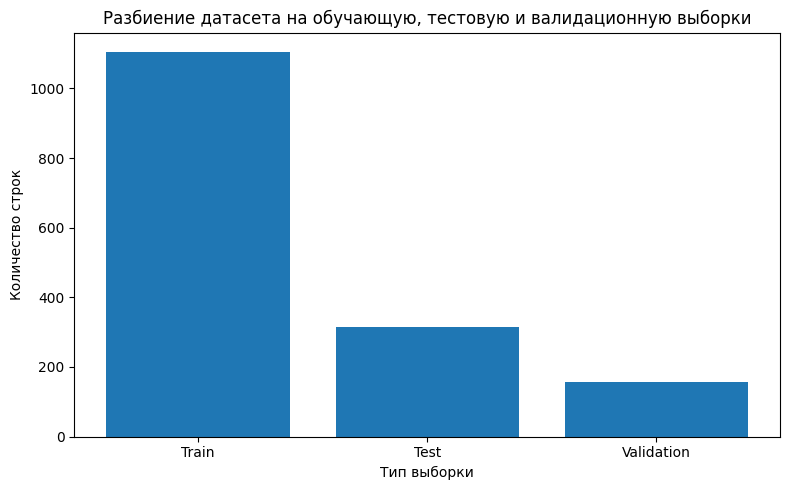

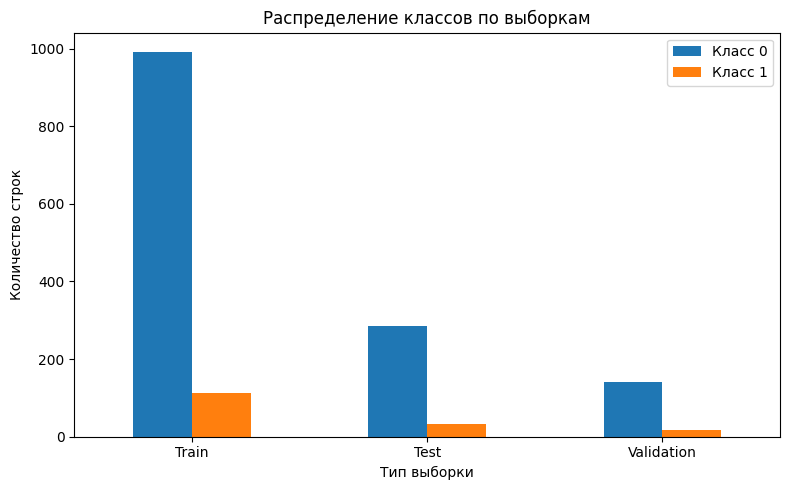

In [156]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()

OUTPUT_DIR = "ml_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


def load_labeled_data() -> pd.DataFrame:
    engine = get_engine()

    query = """
    SELECT
        purchase_object_name,
        label
    FROM labeled_contracts
    WHERE purchase_object_name IS NOT NULL
      AND label IS NOT NULL
    """

    df = pd.read_sql(query, engine)

    df["purchase_object_name"] = df["purchase_object_name"].astype(str).str.strip()
    df = df[df["purchase_object_name"] != ""].copy()

    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])].copy()

    df = df.drop_duplicates().reset_index(drop=True)

    return df


def split_dataset(df: pd.DataFrame):
    X = df["purchase_object_name"]
    y = df["label"]

    # Сначала отделяем train = 70%, temp = 30%
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # Затем temp делим на validation 10% и test 20% от общего объема
    # То есть внутри temp: 1/3 в validation и 2/3 в test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=2/3,
        random_state=42,
        stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


def plot_split_sizes(X_train, X_val, X_test):
    sizes = [len(X_train), len(X_test), len(X_val)]
    labels = ["Train (70%)", "Test (20%)", "Validation (10%)"]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, sizes)
    plt.title("Распределение выборки")
    plt.ylabel("Количество строк")
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "dataset_split.png")
    plt.savefig(plot_path, dpi=150)
    plt.close()

    print(f"График распределения выборки сохранен: {plot_path}")


def build_models():
    models = {
        "logreg": Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_features=5000
            )),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        "random_forest": Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_features=5000
            )),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                random_state=42,
                class_weight="balanced"
            ))
        ]),
        "linear_svc": Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_features=5000
            )),
            ("clf", LinearSVC(
                class_weight="balanced",
                random_state=42
            ))
        ]),
    }

    return models


def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, X_val, y_val):
    model.fit(X_train, y_train)

    # test
    y_pred_test = model.predict(X_test)

    test_metrics = {
        "model_name": model_name,
        "dataset": "test",
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
    }

    # validation
    y_pred_val = model.predict(X_val, y_val) if False else model.predict(X_val)

    val_metrics = {
        "model_name": model_name,
        "dataset": "validation",
        "accuracy": accuracy_score(y_val, y_pred_val),
        "precision": precision_score(y_val, y_pred_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_val, zero_division=0),
        "f1": f1_score(y_val, y_pred_val, zero_division=0),
    }

    print(f"\nМодель: {model_name}")
    print("Метрики на test:")
    print(test_metrics)
    print("Метрики на validation:")
    print(val_metrics)

    print("\nClassification report (test):")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    print("Confusion matrix (test):")
    print(confusion_matrix(y_test, y_pred_test))

    return model, [test_metrics, val_metrics]


def save_metrics(results_df: pd.DataFrame):
    csv_path = os.path.join(OUTPUT_DIR, "model_metrics.csv")
    xlsx_path = os.path.join(OUTPUT_DIR, "model_metrics.xlsx")

    results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    results_df.to_excel(xlsx_path, index=False)

    print(f"Метрики сохранены: {csv_path}")
    print(f"Метрики сохранены: {xlsx_path}")


def choose_best_model(results_df: pd.DataFrame) -> str:
    val_df = results_df[results_df["dataset"] == "validation"].copy()
    val_df = val_df.sort_values(by=["f1", "recall", "precision", "accuracy"], ascending=False)

    best_model_name = val_df.iloc[0]["model_name"]
    return best_model_name


def save_best_model(best_model_name: str, trained_models: dict):
    model = trained_models[best_model_name]

    model_path = os.path.join(OUTPUT_DIR, "best_model.joblib")
    name_path = os.path.join(OUTPUT_DIR, "best_model_name.txt")

    joblib.dump(model, model_path)

    with open(name_path, "w", encoding="utf-8") as f:
        f.write(best_model_name)

    print(f"Лучшая модель сохранена: {model_path}")
    print(f"Название лучшей модели сохранено: {name_path}")


def main():
    df = load_labeled_data()

    print("1. Загружено размеченных строк:", len(df))
    print("2. Распределение классов:")
    print(df["label"].value_counts())

    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(df)

    print("\nРазмеры выборок:")
    print("Train:", len(X_train))
    print("Test:", len(X_test))
    print("Validation:", len(X_val))

    plot_split_sizes(X_train, X_val, X_test)

    models = build_models()

    all_results = []
    trained_models = {}

    for model_name, model in models.items():
        trained_model, metrics_list = evaluate_model(
            model_name=model_name,
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            X_val=X_val,
            y_val=y_val
        )
        trained_models[model_name] = trained_model
        all_results.extend(metrics_list)

    results_df = pd.DataFrame(all_results)
    save_metrics(results_df)

    best_model_name = choose_best_model(results_df)
    print(f"\nЛучшая модель по validation: {best_model_name}")

    save_best_model(best_model_name, trained_models)


    
    # 1. График общего размера выборок
    split_sizes = pd.DataFrame({
        "Выборка": ["Train", "Test", "Validation"],
        "Количество строк": [len(X_train), len(X_test), len(X_val)]
    })
    
    plt.figure(figsize=(8, 5))
    plt.bar(split_sizes["Выборка"], split_sizes["Количество строк"])
    plt.title("Разбиение датасета на обучающую, тестовую и валидационную выборки")
    plt.xlabel("Тип выборки")
    plt.ylabel("Количество строк")
    plt.tight_layout()
    plt.show()
    
    
    # 2. График распределения классов по выборкам
    class_distribution = pd.DataFrame({
        "Train": y_train.value_counts().sort_index(),
        "Test": y_test.value_counts().sort_index(),
        "Validation": y_val.value_counts().sort_index()
    }).fillna(0)
    
    class_distribution.index = ["Класс 0", "Класс 1"]
    
    class_distribution.T.plot(kind="bar", figsize=(8, 5))
    plt.title("Распределение классов по выборкам")
    plt.xlabel("Тип выборки")
    plt.ylabel("Количество строк")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

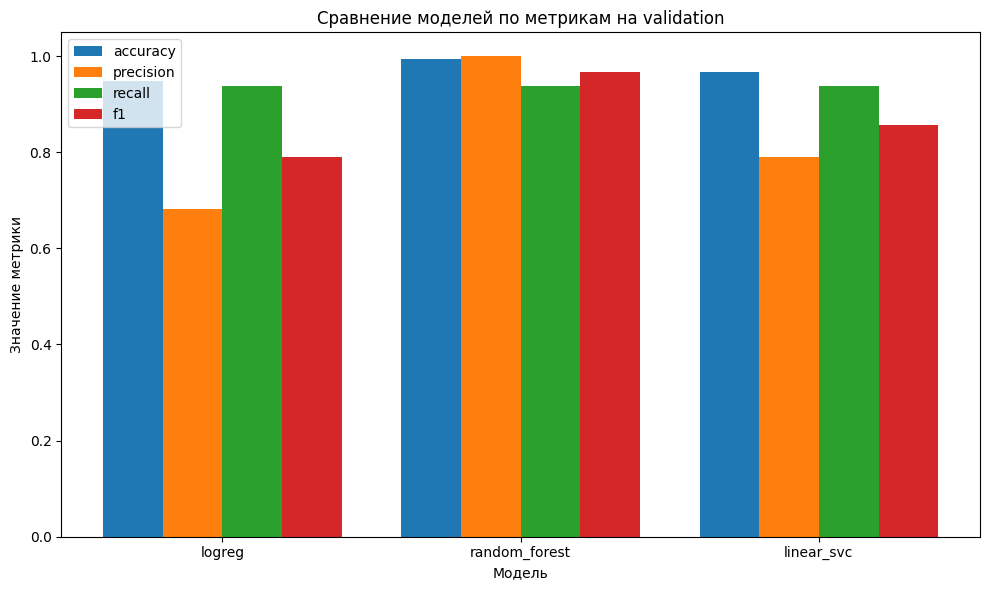

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загружаем результаты
results_df = pd.read_excel("ml_artifacts/model_metrics.xlsx")

# Берем только validation, так как по ней выбирается лучшая модель
val_df = results_df[results_df["dataset"] == "validation"].copy()

metrics = ["accuracy", "precision", "recall", "f1"]
models = val_df["model_name"].tolist()

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, val_df[metric], width=width, label=metric)

plt.xticks(x + width * 1.5, models)
plt.ylim(0, 1.05)
plt.title("Сравнение моделей по метрикам на validation")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

DB_USER = "postgres".strip()
DB_PASSWORD = "onkron1603".strip()
DB_HOST = "localhost".strip()
DB_PORT = "5432".strip()
DB_NAME = "zakupki".strip()


def get_engine():
    url = URL.create(
        drivername="postgresql+psycopg2",
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME
    )
    return create_engine(url)


engine = get_engine()

year_stats = pd.read_sql("SELECT * FROM gold_cardioplegia_year_stats", engine)
customer_stats = pd.read_sql("SELECT * FROM gold_cardioplegia_customer_stats", engine)

year_stats = year_stats.sort_values("contract_year")
customer_stats = customer_stats.sort_values(
    ["total_amount_rub", "contracts_count"],
    ascending=[False, False]
)

display(year_stats)
display(customer_stats.head(10))

,contract_year,contracts_count,total_amount_rub,total_quantity,min_unit_price_rub,max_unit_price_rub,avg_unit_price_rub
0,2019,416,3.322495e+08,51921.0,51.00,831850.00,13575.588918
1,2020,307,1.979299e+08,391852.0,13.39,170098.28,12998.397785
2,2021,340,2.176712e+08,124360.0,5.78,1448236.80,28816.986471
3,2022,289,1.350698e+08,490964.0,21.53,687326.57,15853.445294
4,2023,388,1.133099e+08,385252.0,21.44,248690.00,15936.281727
5,2024,362,1.055468e+08,490078.0,27.13,286779.25,13144.161215
6,2025,100,5.133336e+07,3303.0,821.33,35000.00,13805.372900
7,2026,7,1.271924e+06,100.0,12719.24,28875.00,17335.171429


,customer_name,customer_inn,contracts_count,total_amount_rub,total_quantity,min_unit_price_rub,max_unit_price_rub,avg_unit_price_rub
0,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,2724139667,111,82668530.65,16270.0,295.42,41632.43,6324.070000
1,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,7453215984,21,62560068.31,11075.0,1667.38,19057.66,5218.602381
2,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,7706137673,28,56715325.85,5805.0,1405.00,18754.17,9357.138929
3,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,7802030429,121,55122415.52,7627.0,993.33,286779.25,15547.801736
4,ОБЛАСТНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ...,3124020975,29,52331462.29,31514.0,113.08,197754.00,30630.559655
5,БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХРАНЕНИЯ ВОРОНЕЖСК...,3662006088,81,48787870.53,432681.0,21.87,1448236.80,87177.217654
6,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,3015081689,35,48440088.54,326625.0,21.44,36000.00,5476.128571
7,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ НАУЧНОЕ ...,7704030124,65,43905195.41,9305.0,1230.67,152313.00,10207.250615
8,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,7734012806,13,35077420.26,3142.0,2088.00,18381.33,10881.947692
9,ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕН...,2466228533,62,29862340.99,14955.0,67.34,186486.60,14546.235968


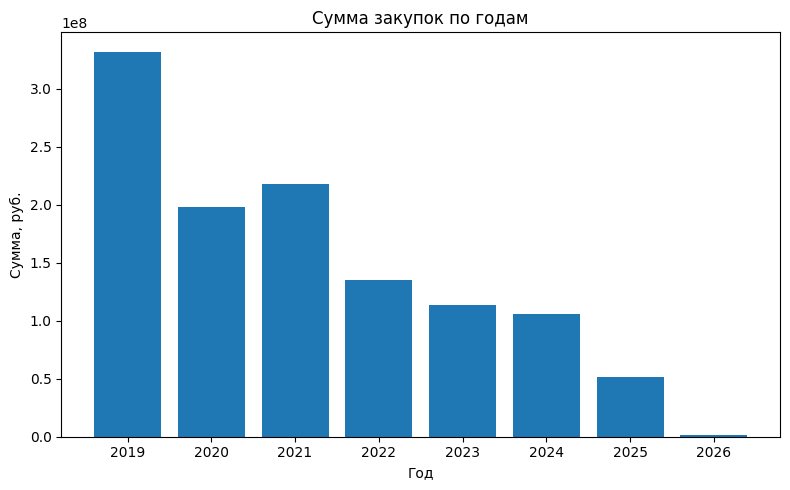

In [143]:
# График 1. Сумма закупок по годам
plt.figure(figsize=(8, 5))
plt.bar(year_stats["contract_year"].astype(str), year_stats["total_amount_rub"])
plt.title("Сумма закупок по годам")
plt.xlabel("Год")
plt.ylabel("Сумма, руб.")
plt.tight_layout()
plt.show()

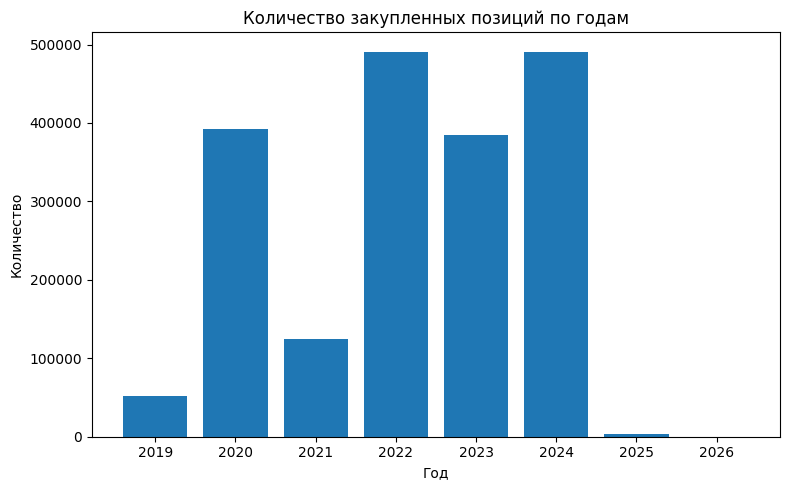

In [144]:
# График 2. Количество закупленных позиций по годам
plt.figure(figsize=(8, 5))
plt.bar(year_stats["contract_year"].astype(str), year_stats["total_quantity"])
plt.title("Количество закупленных позиций по годам")
plt.xlabel("Год")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

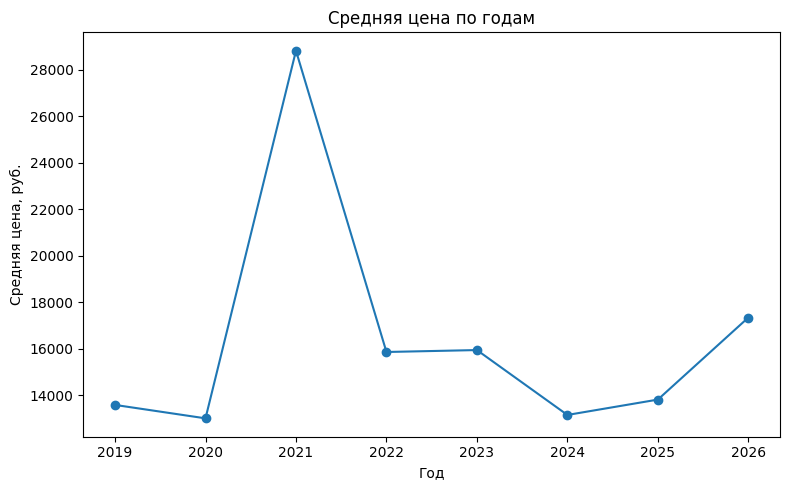

In [145]:
# График 3. Средняя цена по годам
plt.figure(figsize=(8, 5))
plt.plot(year_stats["contract_year"].astype(str), year_stats["avg_unit_price_rub"], marker="o")
plt.title("Средняя цена по годам")
plt.xlabel("Год")
plt.ylabel("Средняя цена, руб.")
plt.tight_layout()
plt.show()

C:\Users\e.turchaninova\AppData\Local\Temp\ipykernel_22000\1913041565.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


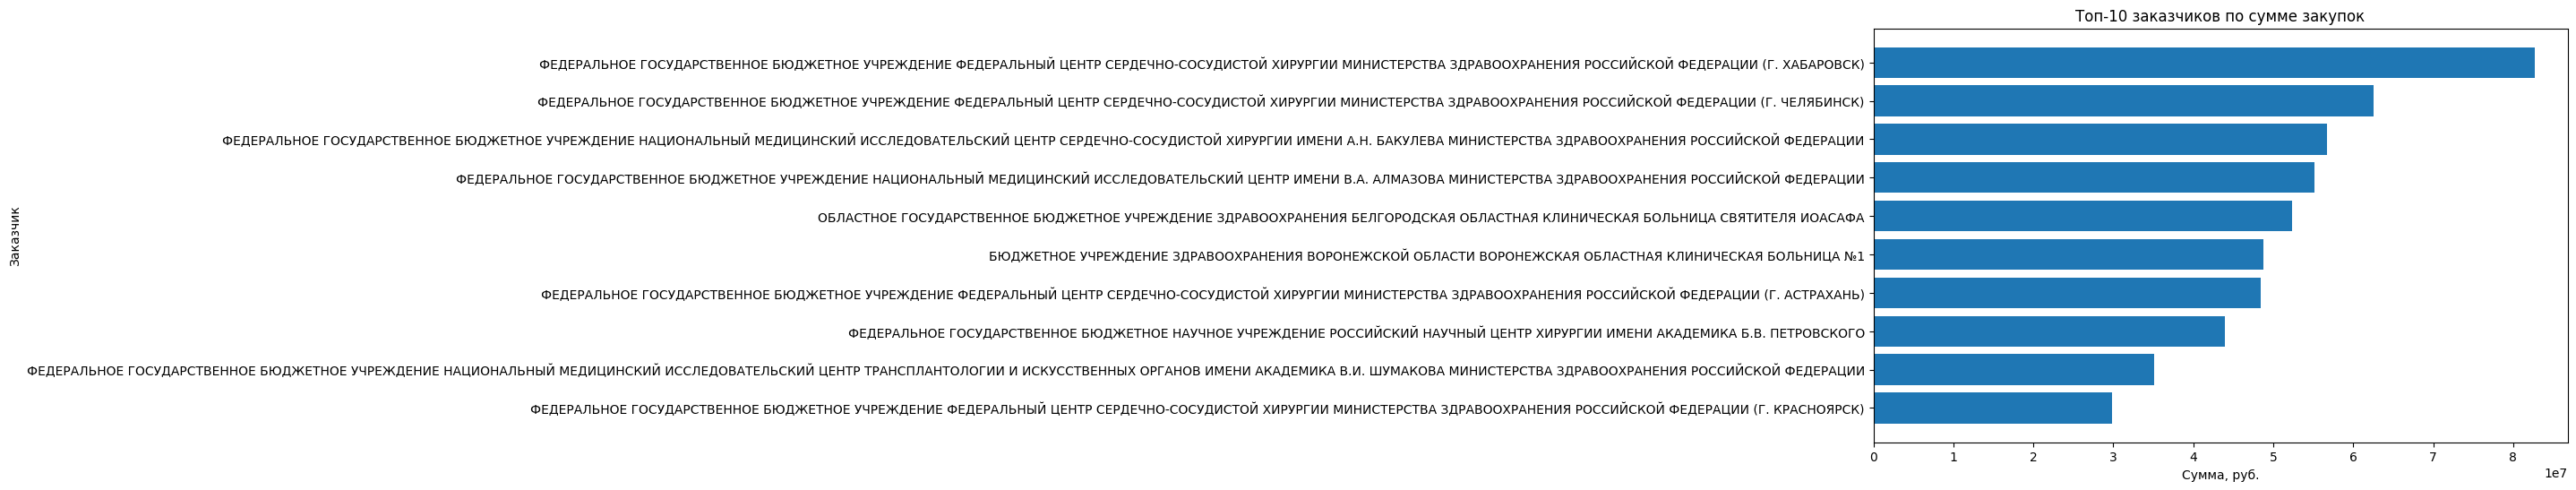

In [146]:
# График 4. Топ-10 заказчиков по сумме закупок
top_amount = customer_stats.head(10).sort_values("total_amount_rub", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_amount["customer_name"], top_amount["total_amount_rub"])
plt.title("Топ-10 заказчиков по сумме закупок")
plt.xlabel("Сумма, руб.")
plt.ylabel("Заказчик")
plt.tight_layout()
plt.show()

C:\Users\e.turchaninova\AppData\Local\Temp\ipykernel_22000\2608558337.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


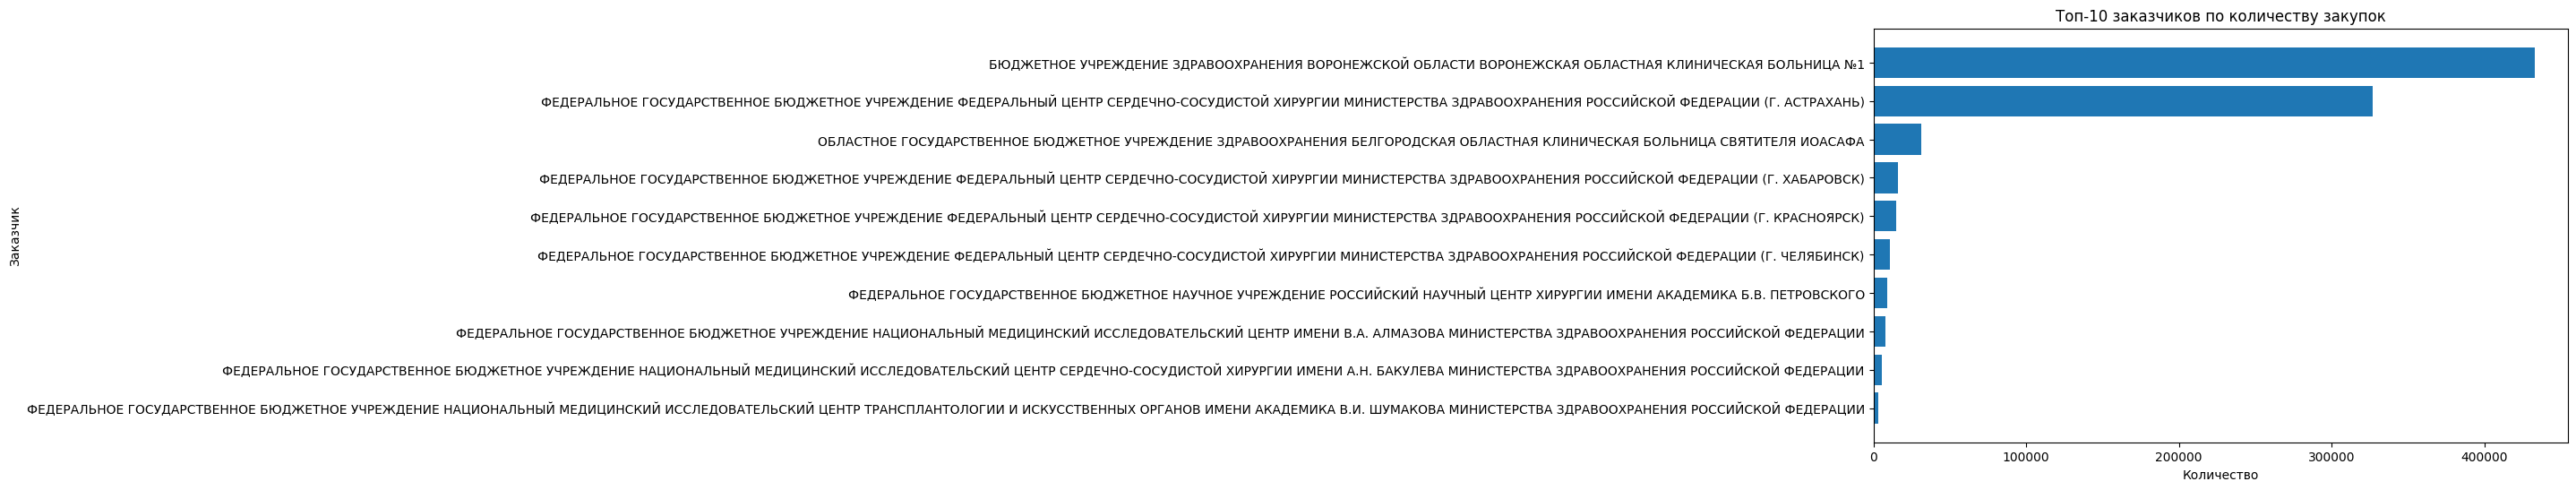

In [147]:
# График 5. Топ-10 заказчиков по количеству закупок
top_qty = customer_stats.head(10).sort_values("total_quantity", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_qty["customer_name"], top_qty["total_quantity"])
plt.title("Топ-10 заказчиков по количеству закупок")
plt.xlabel("Количество")
plt.ylabel("Заказчик")
plt.tight_layout()
plt.show()

In [148]:
scored_df.to_excel('predicted4.xlsx')